# URN to Convolution Quadrature Bridge

This result-bearing notebook records the small teaching bridge from a passive Universal Relaxation Network relaxation fit to Lubich convolution quadrature. The same contract applies to acoustic FEM/BEM and Maxwell time-domain kernels: identify a passive frequency-domain model `H(s)`, then let CQ generate the causal time-history operator.


In [1]:
from pathlib import Path
import json
import sys

repo = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'packages' / 'radia-mcp' / 'src').exists()
)
sys.path.insert(0, str(repo / 'docs' / 'universal_relaxation_network'))

from cq_urn_bridge import build_artifact, plot_artifact

out_dir = repo / 'validation_test' / 'universal_relaxation_network'
artifact = build_artifact(out_dir)
fig_path = plot_artifact(artifact)
summary = {
    'pass': artifact['pass'],
    'schema': artifact['schema'],
    'generated_at_utc': artifact['generated_at_utc'],
    'fit_relative_error': artifact['model']['fit']['relative_error'],
    'active_count': artifact['model']['fit']['active_count'],
    'cq_prehit_max_abs': artifact['cq']['prehit_max_abs'],
    'ifft_prehit_max_abs': artifact['ifft_periodic_contrast']['prehit_max_abs'],
    'figure': str(fig_path),
}
print(json.dumps(summary, indent=2, ensure_ascii=False))


{
  "pass": true,
  "schema": "radia.cq_urn_bridge.v1",
  "generated_at_utc": "2026-09-03T11:55:49Z",
  "fit_relative_error": 2.012493960546964e-16,
  "active_count": 3,
  "cq_prehit_max_abs": 0.0,
  "ifft_prehit_max_abs": 0.7894211091435763,
  "figure": "C:\\temp\\cq_urn_bridge_waveforms.png"
}


## Waveform Check

The CQ curve is causal before the hit. The dashed IFFT curve is deliberately a periodic contrast; it is useful for explaining why a transient demo should state its padding/windowing convention, or use CQ when a Laplace-domain model is available.


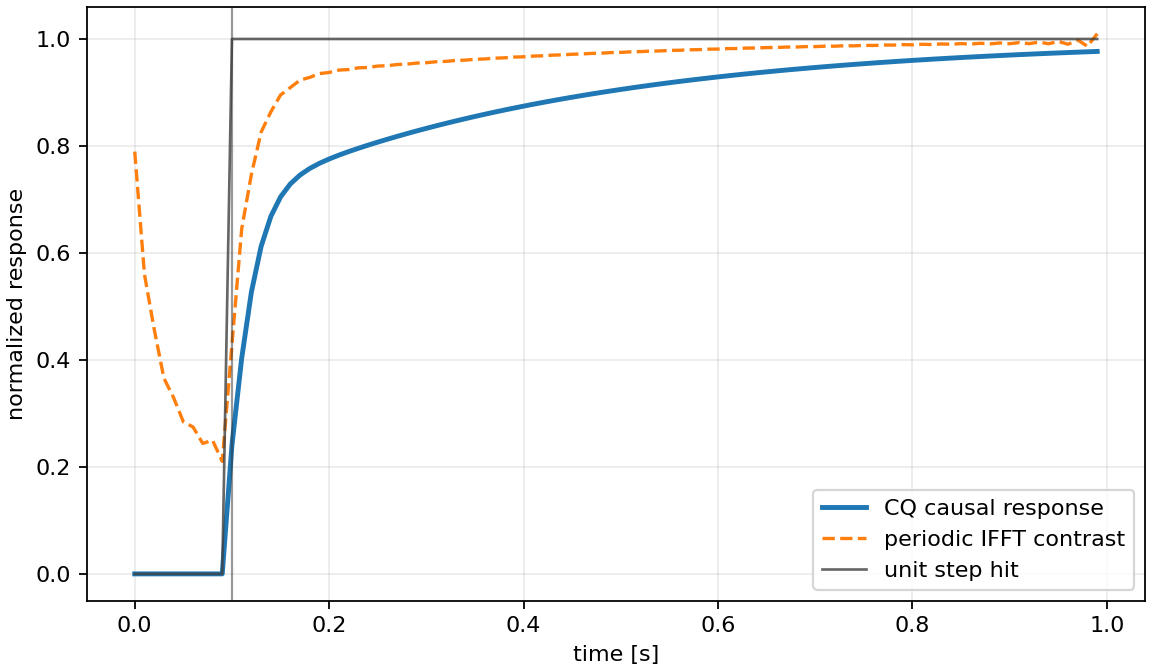

In [2]:
from IPython.display import Image, display
display(Image(filename=str(fig_path)))


## Contract For Solvers

A full acoustic or Maxwell solver should replace only the scalar teaching `H(s)` below. The CQ driver does not care whether `H(s)` came from an impedance boundary, a BEM Schur complement, a dispersive material fit, or a compact URN ladder, as long as the evaluator is passive and causal over the simulation band.


In [3]:
from IPython.display import Markdown, display
fit = artifact['model']['fit']
rows = [
    ('fit relative error', f"{fit['relative_error']:.3e}"),
    ('active passive components', str(fit['active_count'])),
    ('minimum Re H(jw)', f"{artifact['checks']['positive_real_frequency_axis_min']:.3e}"),
    ('CQ pre-hit max abs', f"{artifact['cq']['prehit_max_abs']:.3e}"),
    ('periodic IFFT pre-hit max abs', f"{artifact['ifft_periodic_contrast']['prehit_max_abs']:.3e}"),
]
lines = ['| Check | Value |', '| --- | --- |']
for key, value in rows:
    lines.append(f'| {key} | {value} |')
display(Markdown('\n'.join(lines)))


| Check | Value |
| --- | --- |
| fit relative error | 2.012e-16 |
| active passive components | 3 |
| minimum Re H(jw) | 8.004e-02 |
| CQ pre-hit max abs | 0.000e+00 |
| periodic IFFT pre-hit max abs | 7.894e-01 |

In [4]:
assert artifact['pass'] is True
print(json.dumps(artifact['timing_breakdown_s'], indent=2, ensure_ascii=False))


{
  "fit_nonnegative_debye": 0.5837925000087125,
  "cq_weight_generation": 0.00023620000865776092,
  "convolution_and_ifft_contrast": 0.0001981999957934022,
  "total": 0.5846951999992598
}
